In [ ]:
from PIL import Image
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray

#im_frame = Image.open('Your_Image.png')
#image = (255*rgb2gray(np.array(im_frame))).astype(np.uint8) # 'Your_2D_np_array'

image=np.array(im_gray).astype(np.uint8) #convertir a vector 2D
# Generar GLCM
distances = [50] #Desplazamiento entre pixeles
angles = [np.pi/2]  # Direccion vertical
glcm = graycomatrix(image, distances=distances, angles=angles,levels=255)


# Calcular características de GLCM
contrast = graycoprops(glcm, 'contrast')
dissimilarity = graycoprops(glcm, 'dissimilarity')
homogeneity = graycoprops(glcm, 'homogeneity')
energy = graycoprops(glcm, 'energy')

print(contrast)
print(dissimilarity)
print(homogeneity)
print(energy)

[[1922.22547238]]
[[30.62203985]]
[[0.0800567]]
[[0.02011765]]


## GLCM sobre el conjunto de datos

### Recolección de datos

In [ ]:
import os
import pandas as pd
import kagglehub

# Descargar dataset
dataset_path = kagglehub.dataset_download(
    "obulisainaren/retinal-oct-c8"
)

# Ruta base
base_path = os.path.join(
    dataset_path,
    "RetinalOCT_Dataset/RetinalOCT_Dataset"
)

def crear_dataframe(split_path):
    datos = []

    for clase in os.listdir(split_path):
        clase_path = os.path.join(split_path, clase)

        if os.path.isdir(clase_path):
            for archivo in os.listdir(clase_path):
                datos.append({
                    "filepath": os.path.join(clase_path, archivo),
                    "label": clase
                })

    return pd.DataFrame(datos)

# Crear dataframes
df_train = crear_dataframe(os.path.join(base_path, "train"))
df_val = crear_dataframe(os.path.join(base_path, "val"))
df_test = crear_dataframe(os.path.join(base_path, "test"))

#Verificar dimensiones
print("Train: ", df_train.shape)
print("Val: ", df_val.shape)
print("Test: ", df_test.shape)

100%|██████████| 1.42G/1.42G [00:16<00:00, 91.9MB/s]

Extracting files...


Train:  (18400, 2)
Val:  (2800, 2)
Test:  (2800, 2)


### Exploración y visualización de datos

In [ ]:
#Primero realizaremos una exploración del conjunto de datos
# Imagenes por clase
print(df_train["label"].value_counts())
#Info
print(df_train.info())

label
DME       2300
DRUSEN    2300
CNV       2300
CSR       2300
NORMAL    2300
DR        2300
AMD       2300
MH        2300
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18400 entries, 0 to 18399
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  18400 non-null  object
 1   label     18400 non-null  object
dtypes: object(2)
memory usage: 287.6+ KB
None


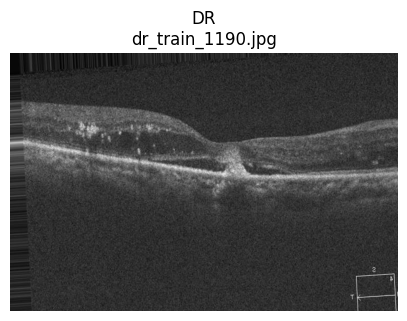

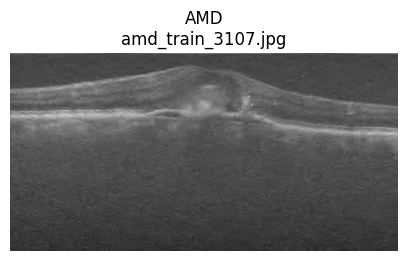

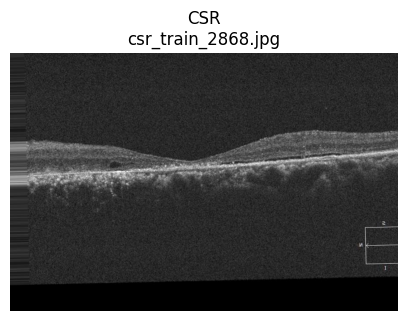

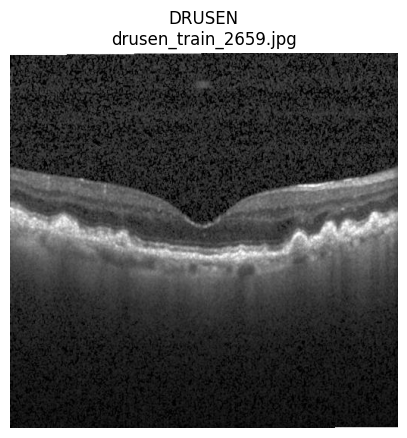

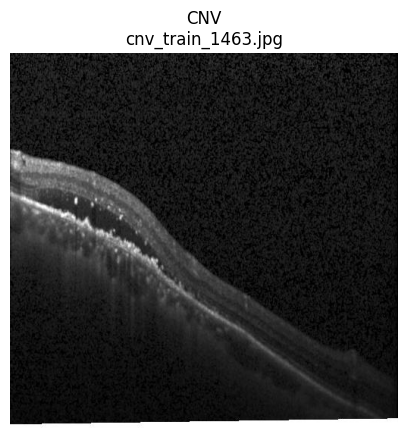

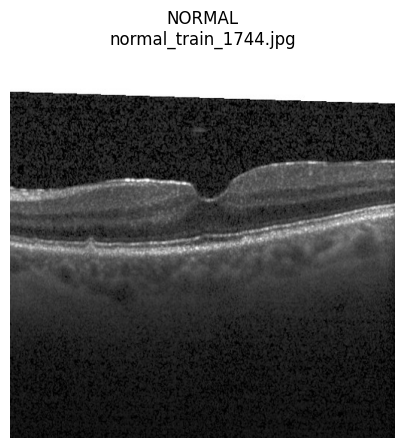

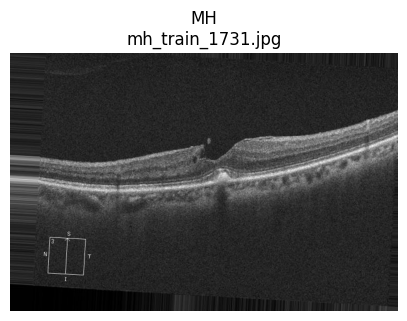

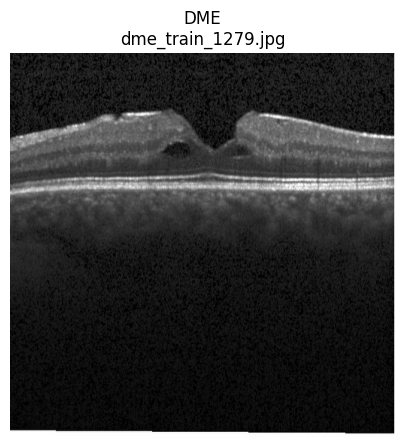

In [ ]:
import random
import os
import cv2 as cv
import matplotlib.pyplot as plt

clases = ["DR", "AMD", "CSR", "DRUSEN", "CNV", "NORMAL", "MH", "DME"]

for clase in clases:
   # Convierte la serie en una lista antes de pasarla a random.choice
    filepaths_for_class = df_train.loc[df_train["label"] == clase, "filepath"].tolist()

    ruta = random.choice(filepaths_for_class)

    img = cv.cvtColor(cv.imread(ruta), cv.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{clase}\n{os.path.basename(ruta)}")
    plt.axis("off")
    plt.show()

### Preprocesamiento
Preprocesamiento esencial:
* Leer imagen
* Redimensionar, se propone 128x128 pero como se utilizará  una CNN es recomendable aumentar


In [ ]:
imagenes = []
etiquetas = []
rutas = []

for clase in clases:
    # Obtener todas las rutas de archivo para la clase actual del dataframe
    filepaths_for_class = df_train.loc[df_train["label"] == clase, "filepath"].tolist()

    for ruta in filepaths_for_class:
        img = cv.imread(ruta)#cargamos la imagen
        img = cv.resize(img, (224, 224))  #Redimensionamos a 128x128 (o esencial para CNN) #Jassiel- Si lo aumenté
        imagenes.append(img)
        etiquetas.append(clase)
        rutas.append(ruta)  #Guardamos la ruta por si es necesario mostrar la imagen original más adelante

print(f"Cantidad total de imágenes preprocesadas: {len(imagenes)}")

Cantidad total de imágenes preprocesadas: 18400


Lo siguiente que se sugiere es calcular un histograma para el espacio HSV. Por ahora lo ignoraremos

In [ ]:
import numpy as np

def extraer_histograma_hsv(img):
    # Se convierte la imagen a HSV
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

    # Se calcula un histograma 3D conjunto sobre los 3 canales (H,S,V ),
    hist = cv.calcHist(
        [hsv],
        [0, 1, 2],
        None,
        [8, 8, 8], # con 8 bins p/canal, igual a 512 valores en total
        [0, 180, 0, 256, 0, 256]  # Rango de valores de H en (0,180), S y V en (0,256)
    )

    # Normalizamos el histograma y se convierte a un vector de una dimension
    hist = cv.normalize(hist, hist).flatten()
    return hist

In [ ]:
# Para calcular la GLCM instalamos scikit-image(en caso de no tenerlo)
!pip install scikit-image

### Calcular descriptores de textura (GLCM)
Toda la estrcutura se puede modificar

In [ ]:
from skimage.feature import graycomatrix, graycoprops

def extraer_glcm(img):
    #Convertimos la imagen a grises por la naturaleza en la que trabaja la matriz
    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1], #se consideran píxeles vecinos a una distancia de 1
        angles=[0],#dirección horizontal
        levels=256, # la imagen en escala de grises tiene 256 niveles posibles
        symmetric=True, #se considera la relación en ambos sentidos, (i,j) y (j,i)
        normed=True #La matriz resultante se normaliza
    )

    # A partir de la GLCM , extraemos 5 propiedades estadísticas de textura
    contraste= graycoprops(glcm, "contrast")[0, 0] # Variación de intensidad entre píxeles vecinos
    homogeneidad = graycoprops(glcm, "homogeneity")[0, 0] # Qué tan uniforme es la textura
    energia = graycoprops(glcm, "energy")[0, 0] # Uniformidad de la distribución
    correlacion = graycoprops(glcm, "correlation")[0, 0]  # Relación lineal entre píxeles vecinos
    asm = graycoprops(glcm, "ASM")[0, 0] # Segundo momento angular

    #Devolvemos las 5 propiedades como un vector
    return np.array([
        contraste,
        homogeneidad,
        energia,
        correlacion,
        asm
    ])

### Extracción de características

In [ ]:
#-Si se emplea HSV+GLCM
def extraer_descriptor(img):
  hsv = extraer_histograma_hsv(img)
  glcm = extraer_glcm(img)

  # Concatenamos ambos vectores en uno solo
  descriptor = np.concatenate([hsv, glcm])

  return descriptor

#-Si se emplea unicamente GLCM
def extraer_descriptor_glcm(img):
  glcm = extraer_glcm(img)
  return glcm


descriptores = []

# Se calcula el descriptor de cada imagen del conjunto de datos
for img in imagenes:
    descriptor = extraer_descriptor_glcm(img)
    descriptores.append(descriptor)

#se convierte la lista de descriptores en un arreglo
descriptores = np.array(descriptores)

print(descriptores.shape)


## Generadores de Datos

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Ruta base
base_path = os.path.join(dataset_path, "RetinalOCT_Dataset/RetinalOCT_Dataset")

# Aumento de datos para entrenamiento + normalización
train_gen = ImageDataGenerator(
    rescale=1./255,           # Normaliza píxeles a [0,1]
    rotation_range=10,        # Rotaciones leves (imágenes médicas, no exagerar)
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)  # Solo normalizar, sin augmentación

# Cargar imágenes directamente desde carpetas
train_data = train_gen.flow_from_directory(
    os.path.join(base_path, "train"),
    target_size=(224, 224),   # MobileNetV2 espera 224x224
    batch_size=32,
    class_mode="categorical"
)

val_data = val_test_gen.flow_from_directory(
    os.path.join(base_path, "val"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

test_data = val_test_gen.flow_from_directory(
    os.path.join(base_path, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False             # Importante para evaluar correctamente
)

print("Clases:", train_data.class_indices)

## Modelo con transfer Learning

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Cargar MobileNetV2 SIN la capa final (include_top=False)
# weights='imagenet' = ya viene entrenada con millones de imágenes
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Congelar la base: no reentrenamos esos pesos todavía
base_model.trainable = False

# Construir el clasificador encima
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Reduce el mapa de características a un vector
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),              # Evita sobreajuste
    layers.Dense(8, activation="softmax")  # 8 clases de salida
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

## Entrenamiento

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Cargar MobileNetV2 SIN la capa final (include_top=False)
# weights='imagenet' = ya viene entrenada con millones de imágenes
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Congelar la base: no reentrenamos esos pesos todavía
base_model.trainable = False

# Construir el clasificador encima
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Reduce el mapa de características a un vector
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),              # Evita sobreajuste
    layers.Dense(8, activation="softmax")  # 8 clases de salida
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

In [ ]:
# Fase 2: Fine-tuning
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Redefinir callbacks (por si la celda anterior no está en memoria)
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("mejor_modelo.keras", save_best_only=True)
]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

historia_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

## Evaluación

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predicciones sobre test
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

# Reporte de precision, recall, F1 por clase
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

# Curva de aprendizaje — usar historia_ft (fine-tuning)
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(historia_ft.history["accuracy"], label="Train")
plt.plot(historia_ft.history["val_accuracy"], label="Val")
plt.title("Accuracy - Fine-tuning")
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia_ft.history["loss"], label="Train")
plt.plot(historia_ft.history["val_loss"], label="Val")
plt.title("Loss - Fine-tuning")
plt.legend()
plt.show()

# Guardar modelo final
model.save("modelo_retina_final.keras")

### Recalcular descriptores GLCM para TODO el train con sus etiquetas

In [ ]:
import numpy as np
import cv2 as cv
from skimage.feature import graycomatrix, graycoprops

# Reutilizo la función de Elvira
def extraer_glcm(img):
    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0],
                        levels=256, symmetric=True, normed=True)
    return np.array([
        graycoprops(glcm, "contrast")[0, 0],
        graycoprops(glcm, "homogeneity")[0, 0],
        graycoprops(glcm, "energy")[0, 0],
        graycoprops(glcm, "correlation")[0, 0],
        graycoprops(glcm, "ASM")[0, 0]
    ])

print("Calculando descriptores GLCM del conjunto de train...")

db_descriptores = []  # vectores GLCM
db_etiquetas = []     # clase de cada imagen
db_rutas = []         # ruta para mostrarla después

for clase in clases:
    filepaths = df_train.loc[df_train["label"] == clase, "filepath"].tolist()
    for ruta in filepaths:
        img = cv.imread(ruta)
        img = cv.resize(img, (224, 224))
        descriptor = extraer_glcm(img)
        db_descriptores.append(descriptor)
        db_etiquetas.append(clase)
        db_rutas.append(ruta)

db_descriptores = np.array(db_descriptores)
print(f"Base de datos CBIR lista: {db_descriptores.shape}")

### Función CBIR

In [ ]:
from scipy.spatial.distance import euclidean, cityblock, cosine
import matplotlib.pyplot as plt

def buscar_similares(img_path, top_k=5, metrica="euclidean"):
    """
    Dada una imagen, clasifica con la CNN y devuelve las top_k más similares
    usando distancia sobre descriptores GLCM.

    metrica: "euclidean", "manhattan" o "cosine"
    """
    # --- Clasificación con CNN ---
    img_orig = cv.imread(img_path)
    img_224 = cv.resize(img_orig, (224, 224))
    img_rgb = cv.cvtColor(img_224, cv.COLOR_BGR2RGB)
    img_input = np.expand_dims(img_rgb / 255.0, axis=0)  # shape (1, 224, 224, 3)

    pred_probs = model.predict(img_input, verbose=0)[0]
    pred_clase_idx = np.argmax(pred_probs)
    pred_clase = list(train_data.class_indices.keys())[pred_clase_idx]
    confianza = pred_probs[pred_clase_idx] * 100

    # --- Descriptor GLCM de la imagen query ---
    query_descriptor = extraer_glcm(img_rgb)

    # --- Calcular distancias contra toda la base ---
    distancias = []
    for i, desc in enumerate(db_descriptores):
        if metrica == "euclidean":
            d = euclidean(query_descriptor, desc)
        elif metrica == "manhattan":
            d = cityblock(query_descriptor, desc)
        elif metrica == "cosine":
            d = cosine(query_descriptor, desc)
        distancias.append(d)

    distancias = np.array(distancias)
    indices_top = np.argsort(distancias)[:top_k]

    # --- Visualización ---
    fig, axes = plt.subplots(1, top_k + 1, figsize=(18, 4))

    # Imagen query
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"QUERY\nDx: {pred_clase}\nConf: {confianza:.1f}%", fontsize=9)
    axes[0].axis("off")

    # Top-K similares
    for j, idx in enumerate(indices_top):
        img_sim = cv.cvtColor(cv.imread(db_rutas[idx]), cv.COLOR_BGR2RGB)
        img_sim = cv.resize(img_sim, (224, 224))
        axes[j+1].imshow(img_sim)
        axes[j+1].set_title(
            f"#{j+1} {db_etiquetas[idx]}\ndist: {distancias[idx]:.4f}", fontsize=9
        )
        axes[j+1].axis("off")

    plt.suptitle(f"CBIR — Métrica: {metrica}", fontsize=11)
    plt.tight_layout()
    plt.show()

    return pred_clase, confianza, [(db_rutas[i], db_etiquetas[i], distancias[i]) for i in indices_top]

Lo probamos

In [ ]:
# Tomar una imagen aleatoria del conjunto de test para probar
import random

clase_prueba = "CNV"  # Cambia por cualquier clase
rutas_test = df_test.loc[df_test["label"] == clase_prueba, "filepath"].tolist()
imagen_prueba = random.choice(rutas_test)

# Ejecutar CBIR
pred, conf, similares = buscar_similares(imagen_prueba, top_k=5, metrica="euclidean")
print(f"\nDiagnóstico: {pred} ({conf:.1f}% confianza)")
print("\nImágenes similares recuperadas:")
for ruta, etiqueta, dist in similares:
    print(f"  {etiqueta} — distancia: {dist:.4f} — {ruta}")